# Treinamento da DenseNet121

Este notebook treina a arquitetura **DenseNet121** na base APTOS 2019 com a divisão estratificada em `train_split.csv`, `val_split.csv` e `test_split.csv`.

Fluxo do notebook:

1. Carregamento dos arquivos de treino, validação e teste.
2. Criação do pipeline TensorFlow.
3. Aplicação de pré-processamento e aumento de dados apenas no treino.
4. Criação do modelo com pesos pré-treinados.
5. Treinamento com pesos por classe.
6. Acompanhamento por validação com callbacks.
7. Avaliação final no conjunto de teste.
8. Salvamento do modelo, histórico, métricas e matriz de confusão.

Observação: este notebook usa rótulos inteiros e `sparse_categorical_crossentropy`, pois isso facilita o uso de `class_weight` no Keras.


## 1. Importações

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# Reprodutibilidade básica.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

# Verifica se existe GPU disponível.
gpus = tf.config.list_physical_devices("GPU")
print("GPUs encontradas:", gpus)

if gpus:
    try:
        # Evita que o TensorFlow tente reservar toda a memória da GPU de uma vez.
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth habilitado para GPU.")
    except Exception as e:
        print("Não foi possível configurar memory growth:", e)
else:
    print("Nenhuma GPU detectada. O treinamento será feito na CPU.")


TensorFlow: 2.21.0
GPUs encontradas: []
Nenhuma GPU detectada. O treinamento será feito na CPU.


## 2. Caminhos do projeto e leitura dos splits

In [2]:
PROJECT_DIR = Path("..")

SPLITS_DIR = PROJECT_DIR / "data" / "splits"
MODELS_DIR = PROJECT_DIR / "models"
METRICS_DIR = PROJECT_DIR / "results" / "metrics"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"
LOGS_DIR = PROJECT_DIR / "results" / "logs"

for directory in [MODELS_DIR, METRICS_DIR, FIGURES_DIR, LOGS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(SPLITS_DIR / "train_split.csv")
val_df = pd.read_csv(SPLITS_DIR / "val_split.csv")
test_df = pd.read_csv(SPLITS_DIR / "test_split.csv")

print("Treino:", train_df.shape)
print("Validação:", val_df.shape)
print("Teste:", test_df.shape)
print("Colunas:", train_df.columns.tolist())

train_df.head()


Treino: (2197, 3)
Validação: (732, 3)
Teste: (733, 3)
Colunas: ['id_code', 'diagnosis', 'image_path']


,id_code,diagnosis,image_path
0,9df31421cdd2,2,G:\caio\tcc-retinopatia-diabetica\data\raw\tra...
1,d3de0d313d61,1,G:\caio\tcc-retinopatia-diabetica\data\raw\tra...
2,bb85097857fa,0,G:\caio\tcc-retinopatia-diabetica\data\raw\tra...
3,abf09c44d5f4,2,G:\caio\tcc-retinopatia-diabetica\data\raw\tra...
4,187f6ccda87a,4,G:\caio\tcc-retinopatia-diabetica\data\raw\tra...


## 3. Configurações gerais

In [3]:
MODEL_KEY = "densenet121"
MODEL_NAME = "DenseNet121"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Use 3 para teste rápido. Na máquina com GPU, altere para 10, 15 ou 20.
EPOCHS = 10

NUM_CLASSES = 5
AUTOTUNE = tf.data.AUTOTUNE

class_names = {
    0: "Sem retinopatia",
    1: "Retinopatia leve",
    2: "Retinopatia moderada",
    3: "Retinopatia severa",
    4: "Retinopatia proliferativa"
}

target_names = [class_names[i] for i in range(NUM_CLASSES)]

print("Modelo:", MODEL_NAME)
print("Tamanho das imagens:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Épocas:", EPOCHS)


Modelo: DenseNet121
Tamanho das imagens: (224, 224)
Batch size: 16
Épocas: 10


## 4. Conferência da distribuição das classes

In [4]:
print("Distribuição no treino:")
print(train_df["diagnosis"].value_counts().sort_index())

print("Distribuição na validação:")
print(val_df["diagnosis"].value_counts().sort_index())

print("Distribuição no teste:")
print(test_df["diagnosis"].value_counts().sort_index())

print("Percentual no treino:")
print((train_df["diagnosis"].value_counts(normalize=True).sort_index() * 100).round(2))

print("Percentual na validação:")
print((val_df["diagnosis"].value_counts(normalize=True).sort_index() * 100).round(2))

print("Percentual no teste:")
print((test_df["diagnosis"].value_counts(normalize=True).sort_index() * 100).round(2))


Distribuição no treino:
diagnosis
0    1083
1     222
2     599
3     116
4     177
Name: count, dtype: int64
Distribuição na validação:
diagnosis
0    361
1     74
2    200
3     38
4     59
Name: count, dtype: int64
Distribuição no teste:
diagnosis
0    361
1     74
2    200
3     39
4     59
Name: count, dtype: int64
Percentual no treino:
diagnosis
0    49.29
1    10.10
2    27.26
3     5.28
4     8.06
Name: proportion, dtype: float64
Percentual na validação:
diagnosis
0    49.32
1    10.11
2    27.32
3     5.19
4     8.06
Name: proportion, dtype: float64
Percentual no teste:
diagnosis
0    49.25
1    10.10
2    27.29
3     5.32
4     8.05
Name: proportion, dtype: float64


## 5. Pesos por classe para reduzir o efeito do desbalanceamento

In [5]:
# Os pesos por classe são calculados apenas com o conjunto de treinamento.
classes = np.unique(train_df["diagnosis"].values)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["diagnosis"].values
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, class_weights_values)
}

class_weights


{0: 0.405724838411819,
 1: 1.9792792792792793,
 2: 0.7335559265442404,
 3: 3.787931034482759,
 4: 2.4824858757062147}

## 6. Pipeline de carregamento das imagens

As imagens são lidas a partir da coluna `image_path`, redimensionadas para `224 x 224` e mantidas em `float32`.

Importante: aqui **não dividimos por 255**. O pré-processamento específico de cada arquitetura é aplicado dentro do modelo, usando a função `preprocess_input` apropriada.


In [6]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    # Mantemos o rótulo como inteiro para usar sparse_categorical_crossentropy.
    label = tf.cast(label, tf.int32)

    return image, label


def make_dataset(df, shuffle=False):
    image_paths = df["image_path"].values
    labels = df["diagnosis"].values

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=SEED, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

for images, labels in train_ds.take(1):
    print("Formato das imagens de treino:", images.shape)
    print("Formato dos rótulos de treino:", labels.shape)
    print("Menor valor de pixel:", tf.reduce_min(images).numpy())
    print("Maior valor de pixel:", tf.reduce_max(images).numpy())

for images, labels in val_ds.take(1):
    print("Formato das imagens de validação:", images.shape)
    print("Formato dos rótulos de validação:", labels.shape)

for images, labels in test_ds.take(1):
    print("Formato das imagens de teste:", images.shape)
    print("Formato dos rótulos de teste:", labels.shape)


Formato das imagens de treino: (16, 224, 224, 3)
Formato dos rótulos de treino: (16,)
Menor valor de pixel: 0.0
Maior valor de pixel: 255.0
Formato das imagens de validação: (16, 224, 224, 3)
Formato dos rótulos de validação: (16,)
Formato das imagens de teste: (16, 224, 224, 3)
Formato dos rótulos de teste: (16,)


## 7. Aumento de dados aplicado apenas ao treino

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03, fill_mode="constant", fill_value=0.0),
    tf.keras.layers.RandomZoom(0.05, fill_mode="constant", fill_value=0.0),
    tf.keras.layers.RandomTranslation(0.03, 0.03, fill_mode="constant", fill_value=0.0),
    tf.keras.layers.RandomFlip("horizontal"),
], name="data_augmentation")


def apply_augmentation(images, labels):
    images = data_augmentation(images, training=True)
    return images, labels


train_ds_augmented = train_ds.map(
    apply_augmentation,
    num_parallel_calls=AUTOTUNE
)

for images, labels in train_ds_augmented.take(1):
    print("Formato das imagens aumentadas:", images.shape)
    print("Formato dos rótulos:", labels.shape)


Formato das imagens aumentadas: (16, 224, 224, 3)
Formato dos rótulos: (16,)


## 8. Visualização rápida do aumento de dados

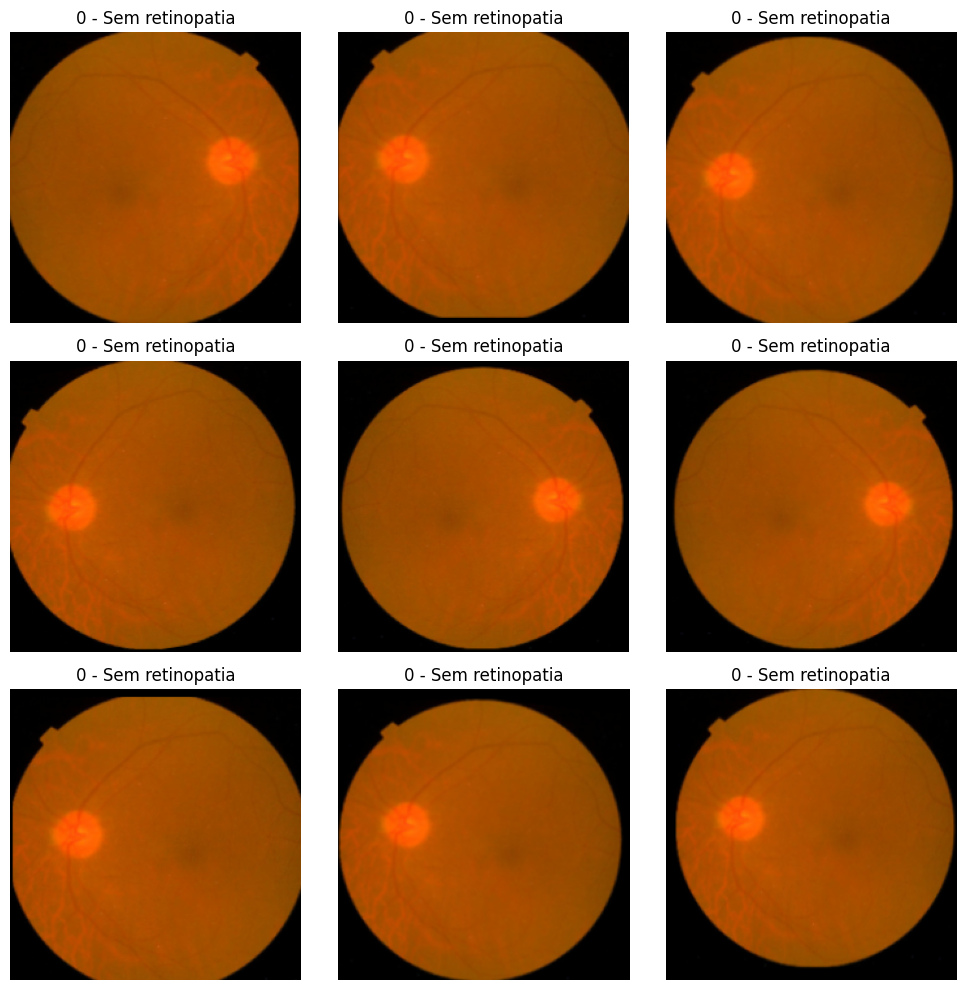

In [8]:
for images, labels in train_ds.take(1):
    image = images[0]
    label = int(labels[0].numpy())

    plt.figure(figsize=(10, 10))

    for i in range(9):
        augmented_image = data_augmentation(
            tf.expand_dims(image, axis=0),
            training=True
        )

        plt.subplot(3, 3, i + 1)
        # Divide por 255 apenas para visualização, pois os pixels estão em 0-255.
        plt.imshow(tf.clip_by_value(augmented_image[0] / 255.0, 0, 1).numpy())
        plt.title(f"{label} - {class_names[label]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


## 9. Criação do modelo DenseNet121

In [9]:
# Pré-processamento específico da arquitetura.
preprocess_input = tf.keras.applications.densenet.preprocess_input

base_model = tf.keras.applications.densenet.DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Primeira fase: congela a base pré-treinada e treina apenas a cabeça de classificação.
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3), name="input_image")

x = tf.keras.layers.Lambda(preprocess_input, name="preprocess_input")(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dropout(0.3, name="dropout")(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classification_output"
)(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name=f"{MODEL_KEY}_APTOS")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step



Model: "densenet121_APTOS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_input (Lambda)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_output (Dense)   │ (None, 5)              │         5,125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,042,629 (26.87 MB)

 Trainable params: 5,125 (20.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

## 10. Callbacks de treinamento

In [10]:
MODEL_OUTPUT_DIR = MODELS_DIR / MODEL_KEY
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_path = MODEL_OUTPUT_DIR / f"{MODEL_KEY}_best.keras"
csv_log_path = LOGS_DIR / f"{MODEL_KEY}_training_log.csv"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        filename=csv_log_path,
        append=False
    )
]

print("Checkpoint:", checkpoint_path)
print("Log CSV:", csv_log_path)


Checkpoint: ..\models\densenet121\densenet121_best.keras
Log CSV: ..\results\logs\densenet121_training_log.csv


## 11. Treinamento

In [11]:
history = model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.2606 - loss: 1.8630
Epoch 1: val_loss improved from None to 1.57104, saving model to ..\models\densenet121\densenet121_best.keras

Epoch 1: finished saving model to ..\models\densenet121\densenet121_best.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 138s 796ms/step - accuracy: 0.2754 - loss: 1.8050 - val_accuracy: 0.2828 - val_loss: 1.5710 - learning_rate: 1.0000e-04
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.3477 - loss: 1.6773
Epoch 2: val_loss improved from 1.57104 to 1.43928, saving model to ..\models\densenet121\densenet121_best.keras

Epoch 2: finished saving model to ..\models\densenet121\densenet121_best.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 117s 774ms/step - accuracy: 0.3473 - loss: 1.6757 - val_accuracy: 0.4057 - val_loss: 1.4393 - learning_rate: 1.0000e-04
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.4054 - loss: 1.5718
Epoch 3: val_loss improved from 1.43928 to 1.41928, sav

## 12. Salvamento do histórico de treinamento

In [12]:
history_df = pd.DataFrame(history.history)
history_path = METRICS_DIR / f"{MODEL_KEY}_history.csv"
history_df.to_csv(history_path, index=False)

history_df


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.275376,1.805019,0.282787,1.571035,0.0001
1,0.347292,1.675719,0.405738,1.439276,0.0001
2,0.419208,1.585976,0.456284,1.419276,0.0001
3,0.464725,1.538732,0.497268,1.343152,0.0001
4,0.493855,1.485794,0.513661,1.298982,0.0001
5,0.518889,1.383798,0.530055,1.206776,0.0001
6,0.543013,1.351142,0.534153,1.227462,0.0001
7,0.543924,1.353999,0.561475,1.140382,0.0001
8,0.571689,1.306752,0.579235,1.083648,0.0001
9,0.580792,1.322953,0.569672,1.086053,0.0001


## 13. Gráficos de treinamento e validação

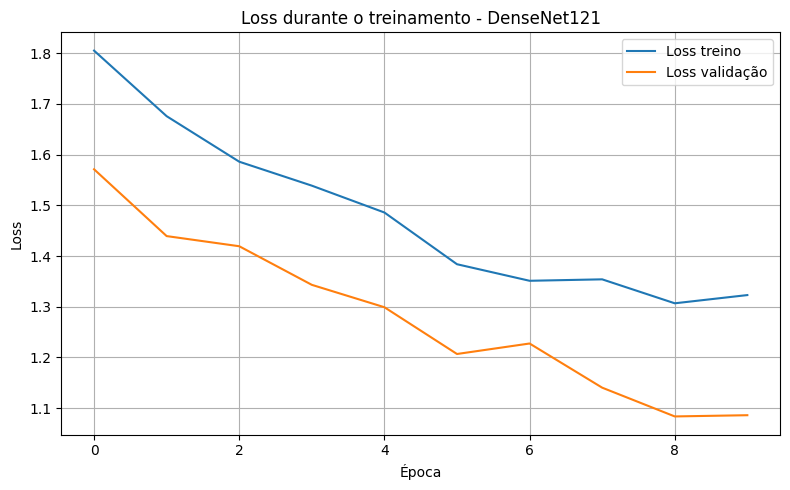

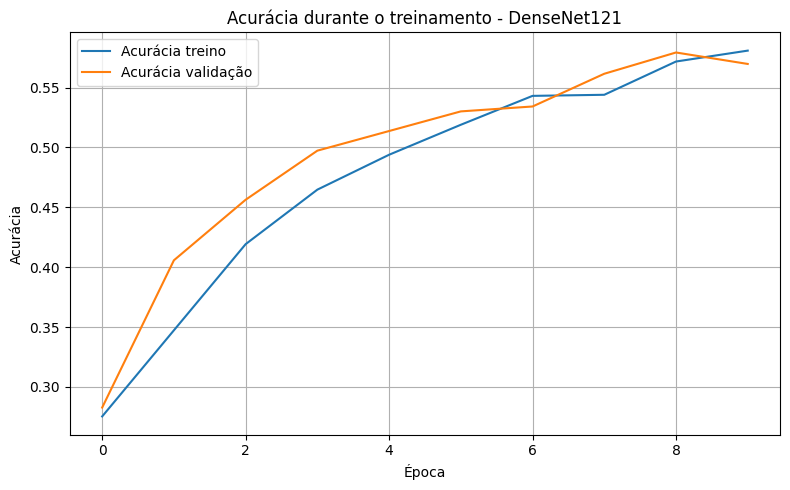

Figuras salvas em:
..\results\figures\densenet121_loss.png
..\results\figures\densenet121_accuracy.png


In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Loss treino")

if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="Loss validação")

plt.title(f"Loss durante o treinamento - {MODEL_NAME}")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_fig_path = FIGURES_DIR / f"{MODEL_KEY}_loss.png"
plt.savefig(loss_fig_path, dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Acurácia treino")

if "val_accuracy" in history.history:
    plt.plot(history.history["val_accuracy"], label="Acurácia validação")

plt.title(f"Acurácia durante o treinamento - {MODEL_NAME}")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.tight_layout()

acc_fig_path = FIGURES_DIR / f"{MODEL_KEY}_accuracy.png"
plt.savefig(acc_fig_path, dpi=300)
plt.show()

print("Figuras salvas em:")
print(loss_fig_path)
print(acc_fig_path)


## 14. Avaliação no conjunto de teste

In [14]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Loss no teste:", test_loss)
print("Acurácia no teste:", test_accuracy)

summary_metrics = {
    "model": MODEL_NAME,
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "epochs_configured": int(EPOCHS),
    "epochs_completed": int(len(history.history.get("loss", []))),
    "batch_size": int(BATCH_SIZE),
    "image_size": list(IMG_SIZE),
    "class_weights": class_weights,
    "split_strategy": "60% treino / 20% validação / 20% teste",
    "gpu_available": bool(tf.config.list_physical_devices("GPU"))
}

summary_path = METRICS_DIR / f"{MODEL_KEY}_summary_metrics.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary_metrics, f, indent=4, ensure_ascii=False)

print("Resumo salvo em:", summary_path)


46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 648ms/step - accuracy: 0.5935 - loss: 1.0418
Loss no teste: 1.041751503944397
Acurácia no teste: 0.5934515595436096
Resumo salvo em: ..\results\metrics\densenet121_summary_metrics.json


## 15. Predições no conjunto de teste

In [15]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Quantidade de rótulos reais:", len(y_true))
print("Quantidade de predições:", len(y_pred))
print("Classes previstas:", np.unique(y_pred, return_counts=True))


Quantidade de rótulos reais: 733
Quantidade de predições: 733
Classes previstas: (array([0, 1, 2, 3, 4]), array([338, 133,  38,  68, 156]))


## 16. Relatório de classificação

In [16]:
report = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=target_names,
    digits=4,
    zero_division=0
)

print(report)

report_path = METRICS_DIR / f"{MODEL_KEY}_classification_report.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("Relatório salvo em:", report_path)


                           precision    recall  f1-score   support

          Sem retinopatia     0.9290    0.8698    0.8984       361
         Retinopatia leve     0.3684    0.6622    0.4734        74
     Retinopatia moderada     0.7105    0.1350    0.2269       200
       Retinopatia severa     0.2059    0.3590    0.2617        39
Retinopatia proliferativa     0.1987    0.5254    0.2884        59

                 accuracy                         0.5935       733
                macro avg     0.4825    0.5103    0.4298       733
             weighted avg     0.7155    0.5935    0.5893       733

Relatório salvo em: ..\results\metrics\densenet121_classification_report.txt


## 17. Matriz de confusão

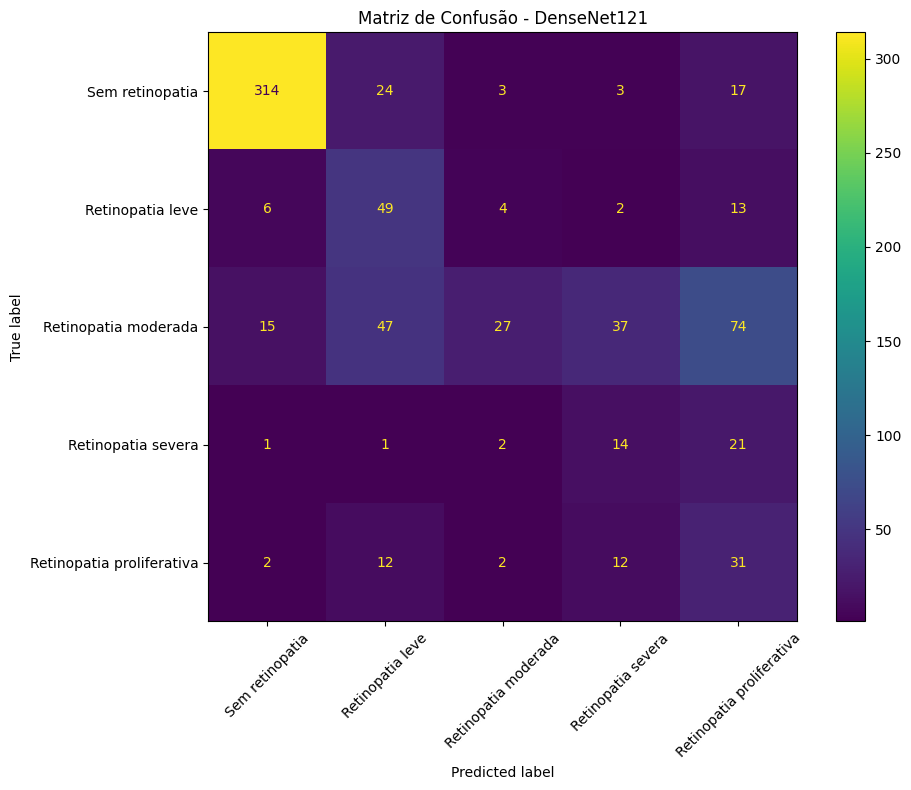

Matriz CSV salva em: ..\results\metrics\densenet121_confusion_matrix.csv
Figura salva em: ..\results\figures\densenet121_confusion_matrix.png


In [17]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

cm_path = METRICS_DIR / f"{MODEL_KEY}_confusion_matrix.csv"
pd.DataFrame(cm, index=target_names, columns=target_names).to_csv(cm_path)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="viridis", values_format="d")
plt.title(f"Matriz de Confusão - {MODEL_NAME}")
plt.tight_layout()

cm_fig_path = FIGURES_DIR / f"{MODEL_KEY}_confusion_matrix.png"
plt.savefig(cm_fig_path, dpi=300)
plt.show()

print("Matriz CSV salva em:", cm_path)
print("Figura salva em:", cm_fig_path)


## 18. Salvamento final do modelo

In [18]:
final_model_path = MODEL_OUTPUT_DIR / f"{MODEL_KEY}_final.keras"
model.save(final_model_path)

print("Modelo final salvo em:", final_model_path)
print("Melhor checkpoint salvo em:", checkpoint_path)


Modelo final salvo em: ..\models\densenet121\densenet121_final.keras
Melhor checkpoint salvo em: ..\models\densenet121\densenet121_best.keras
